# Inspect PFC signal: unthresholded second-level T-maps

Extracts T-value distributions from group-level SPM T-maps within prefrontal and
reference ROIs to diagnose whether PFC is silent due to absent signal (T ≈ 0)
or insufficient power (subthreshold but present).

**ROIs** — built from the Harvard-Oxford probabilistic atlas (25% threshold):
- Prefrontal: OFC, vmPFC, ACC, dlPFC
- Reference: Striatum, Occipital

**Key metrics per ROI:**
- Mean T-value
- % voxels with T > 0
- % voxels with T > 3.0 (≈ p < 0.001 uncorrected)


In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, plotting
from nilearn.datasets import fetch_atlas_harvard_oxford


In [2]:
PROB_THRESH = 25  # minimum % probability to include a voxel in a region

ho_cort = fetch_atlas_harvard_oxford('cort-prob-2mm')
ho_sub  = fetch_atlas_harvard_oxford('sub-prob-2mm')

cort_4d = image.load_img(ho_cort.maps)
sub_4d  = image.load_img(ho_sub.maps)


def make_roi(atlas_4d, labels, name_fragments):
    """Binary mask: union of atlas regions whose label contains any fragment."""
    data    = atlas_4d.get_fdata()
    indices = [i for i, l in enumerate(labels)
               if any(f.lower() in l.lower() for f in name_fragments)]
    if not indices:
        raise ValueError(f"No labels matched: {name_fragments}\n"
                         f"Available: {labels}")
    combined = data[..., indices].max(axis=-1)
    return image.new_img_like(atlas_4d, (combined >= PROB_THRESH).astype(np.int8))


rois = {
    "OFC":       make_roi(cort_4d, ho_cort.labels, ["Frontal Orbital Cortex"]),
    "vmPFC":     make_roi(cort_4d, ho_cort.labels, ["Frontal Medial Cortex", "Paracingulate Gyrus"]),
    "ACC":       make_roi(cort_4d, ho_cort.labels, ["Cingulate Gyrus, anterior"]),
    "dlPFC":     make_roi(cort_4d, ho_cort.labels, ["Middle Frontal Gyrus", "Superior Frontal Gyrus"]),
    "Striatum":  make_roi(sub_4d,  ho_sub.labels,  ["Caudate", "Putamen"]),
    "Occipital": make_roi(cort_4d, ho_cort.labels, ["Lateral Occipital"]),
}

PFC_ROIS = ["OFC", "vmPFC", "ACC", "dlPFC"]
REF_ROIS = ["Striatum", "Occipital"]

print("ROI voxel counts (2 mm MNI):")
for name, img in rois.items():
    print(f"  {name:<12} {int(img.get_fdata().sum()):>5d} voxels")


[fetch_atlas_harvard_oxford] Dataset found in /Users/hugofluhr/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/hugofluhr/nilearn_data/fsl
ROI voxel counts (2 mm MNI):
  OFC           1367 voxels
  vmPFC         4698 voxels
  ACC           2825 voxels
  dlPFC         6952 voxels
  Striatum      2828 voxels
  Occipital     6189 voxels


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_68946/635156541.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


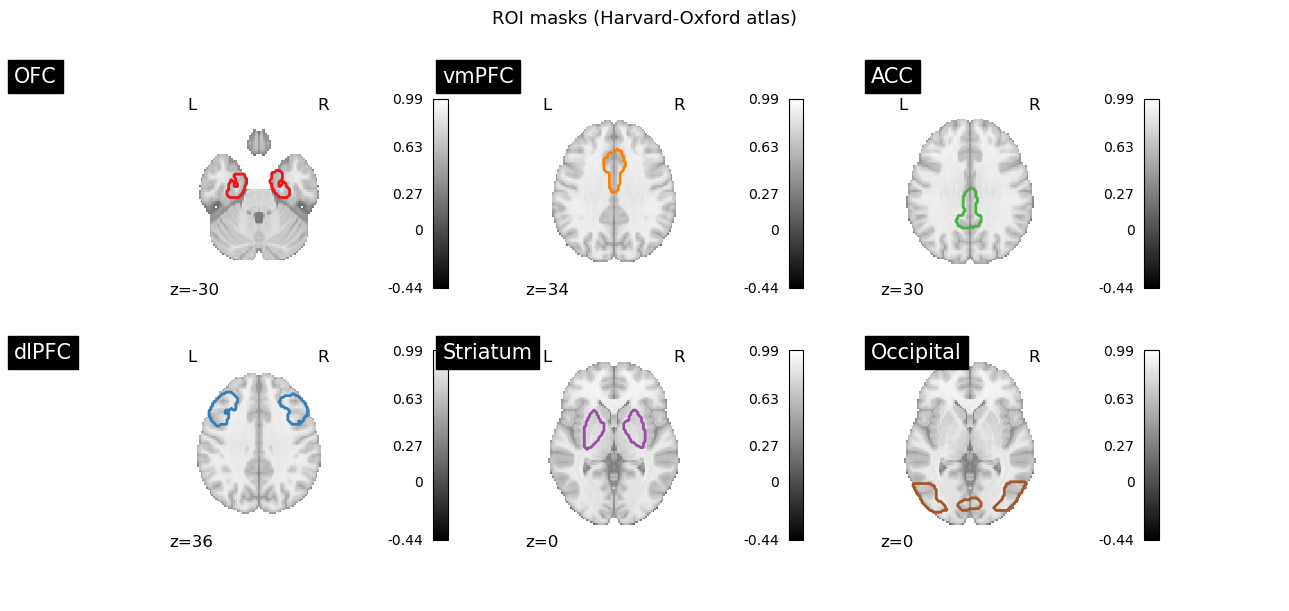

In [4]:
colors = {"OFC": "#e41a1c", "vmPFC": "#ff7f00", "ACC": "#4daf4a",
          "dlPFC": "#377eb8", "Striatum": "#984ea3", "Occipital": "#a65628"}

def roi_centroid_mm(roi_img):
    """MNI mm coordinate of the ROI's centre of mass."""
    data = roi_img.get_fdata()
    vox  = np.argwhere(data > 0).mean(axis=0)
    return (roi_img.affine @ np.append(vox, 1))[:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (name, roi_img) in zip(axes.flat, rois.items()):
    cx, cy, cz = roi_centroid_mm(roi_img)
    display = plotting.plot_anat(
        axes=ax, display_mode='z', cut_coords=[cz],
        title=name, draw_cross=False, annotate=True,
    )
    display.add_contours(roi_img, colors=[colors[name]], levels=[0.5], linewidths=2)

plt.suptitle("ROI masks (Harvard-Oxford atlas)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
BASE_GLM2 = "/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_all_runs_scrubbed_2025-12-11-12-44/second-lvl"
BASE_CHOSEN = "/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_chosen_all_runs_scrubbed_2026-03-17-02-53/second-lvl"

TMAP_PATHS = {
    "1st stim × Q-val":      f"{BASE_GLM2}/first_stimxqval/spmT_0001.nii",
    "1st stim × H-val":      f"{BASE_GLM2}/first_stimxhval/spmT_0001.nii",
    "2nd stim × Q-val":      f"{BASE_GLM2}/second_stimxqval/spmT_0001.nii",
    "2nd stim × H-val":      f"{BASE_GLM2}/second_stimxhval/spmT_0001.nii",
    "chosen × Q-val":        f"{BASE_CHOSEN}/second_stimxqval_chosen/spmT_0001.nii",
    "chosen × H-val":        f"{BASE_CHOSEN}/second_stimxhval_chosen/spmT_0001.nii",
}

# ---------------------------------------------------------------------------

def extract_tvals(tmap_path, roi_img):
    """T-values within roi_img after resampling to T-map space."""
    tmap    = nib.load(tmap_path)
    roi_res = image.resample_to_img(roi_img, tmap, interpolation='nearest')
    mask    = roi_res.get_fdata() > 0
    tvals   = tmap.get_fdata()[mask]
    return tvals[np.isfinite(tvals)]


records = []
for contrast, path in TMAP_PATHS.items():
    for roi_name, roi_img in rois.items():
        tvals = extract_tvals(path, roi_img)
        records.append(dict(
            contrast=contrast,
            roi=roi_name,
            tvals=tvals,
            mean_t=round(tvals.mean(), 3),
            pct_pos=round((tvals > 0).mean() * 100, 1),
            pct_thr=round((tvals > 3.0).mean() * 100, 1),
        ))

df_tvals = pd.DataFrame(records)

summary = df_tvals[["contrast", "roi", "mean_t", "pct_pos", "pct_thr"]].copy()
summary.columns = ["Contrast", "ROI", "Mean T", "% T>0", "% T>3.0"]
print(summary.to_string(index=False))


        Contrast       ROI  Mean T  % T>0  % T>3.0
1st stim × Q-val       OFC  -0.007    0.3      0.0
1st stim × Q-val     vmPFC   1.298   85.8      8.0
1st stim × Q-val       ACC   0.163   53.9      0.7
1st stim × Q-val     dlPFC   1.313   79.0     11.9
1st stim × Q-val  Striatum   0.574   65.2      1.3
1st stim × Q-val Occipital   1.249   62.3     18.8
1st stim × H-val       OFC   0.025    1.8      0.0
1st stim × H-val     vmPFC  -0.954   18.4      0.0
1st stim × H-val       ACC  -0.310   41.8      2.0
1st stim × H-val     dlPFC  -1.334   17.6      0.0
1st stim × H-val  Striatum  -0.357   42.0      0.0
1st stim × H-val Occipital  -3.761    0.0      0.0
2nd stim × Q-val       OFC   0.004    0.9      0.0
2nd stim × Q-val     vmPFC  -0.084   46.3      0.0
2nd stim × Q-val       ACC   0.117   49.7      1.7
2nd stim × Q-val     dlPFC   0.077   50.9      0.1
2nd stim × Q-val  Striatum   0.576   67.7      0.3
2nd stim × Q-val Occipital   2.142   77.6     32.0
2nd stim × H-val       OFC   0.

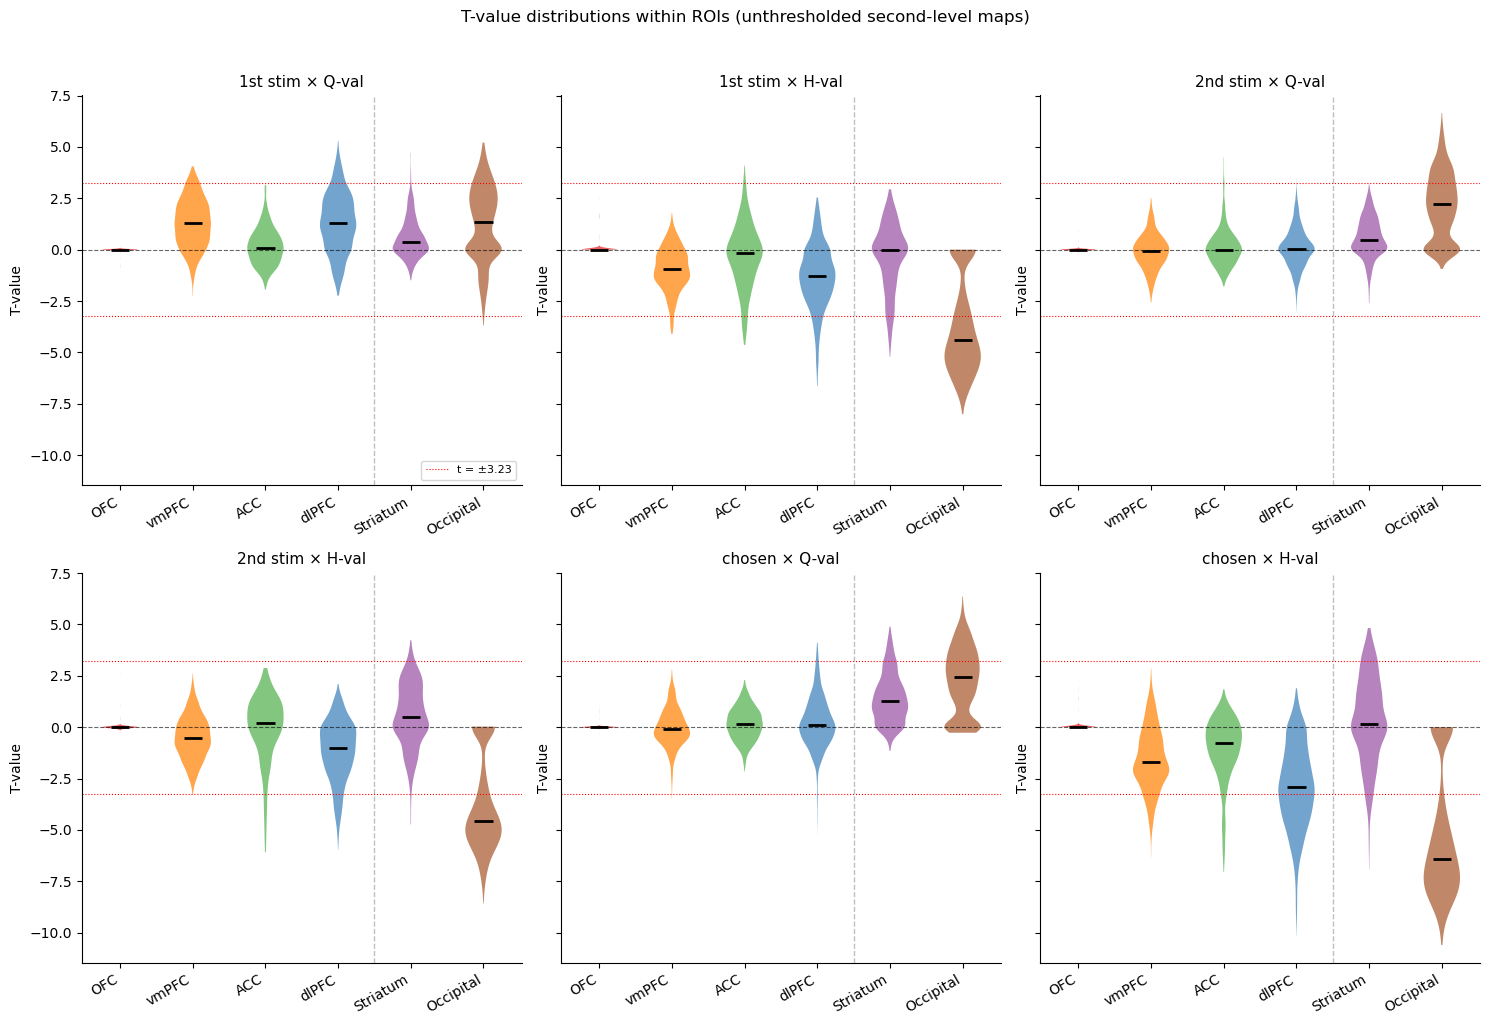

In [16]:
contrasts = list(TMAP_PATHS.keys())
roi_order = PFC_ROIS + REF_ROIS

ncols = 3
nrows = int(np.ceil(len(contrasts) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), sharey=True)

for ax, contrast in zip(axes.flat, contrasts):
    subset = df_tvals[df_tvals["contrast"] == contrast].set_index("roi")
    data   = [subset.loc[r, "tvals"] for r in roi_order]

    parts = ax.violinplot(data, positions=range(len(roi_order)),
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], [colors[r] for r in roi_order]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.axhline(0,    color="black", lw=0.8, ls="--", alpha=0.6)
    ax.axhline(3.23,  color="red",   lw=0.8, ls=":",  label="t = ±3.23")
    ax.axhline(-3.23, color="red",   lw=0.8, ls=":")
    ax.axvline(len(PFC_ROIS) - 0.5, color="gray", lw=1, ls="--", alpha=0.5)
    ax.set_xticks(range(len(roi_order)))
    ax.set_xticklabels(roi_order, rotation=30, ha="right")
    ax.set_title(contrast, fontsize=11)
    ax.set_ylabel("T-value")
    ax.spines[["top", "right"]].set_visible(False)

# Hide unused axes if contrasts don't fill the grid
for ax in axes.flat[len(contrasts):]:
    ax.set_visible(False)

axes.flat[0].legend(fontsize=8, loc="lower right")
plt.suptitle("T-value distributions within ROIs (unthresholded second-level maps)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Interpretation

### OFC: signal dropout

OFC is essentially absent from the GLM mask. Across all contrasts, mean T ≈ 0 and only 0.3–1.8% of voxels have T > 0 — with genuine noise the expected value is ~50%. The near-total absence of positive T-values means the vast majority of OFC voxels sit at exactly T = 0 in the SPM T-map, i.e. they were excluded by the brain mask during GLM estimation. This is expected: OFC sits directly above the sinuses and is routinely lost to susceptibility-induced signal dropout. Nothing to recover here without field maps or a targeted acquisition.

### vmPFC: adequate signal, effect is absent

vmPFC and dlPFC are clearly inside the mask. For **1st stim × Q-val**, vmPFC has 86% of voxels with T > 0 (mean T = 1.3) and dlPFC has 79% (mean T = 1.3). tSNR in vmPFC = 74.4, well above the whole-brain mean of 62.3 — signal quality is not the issue. SVC in vmPFC did not survive, confirming that the Q-value effect there is too small or absent at the group level, not masked by noise.

### ACC: weakly present, no consistent direction

ACC sits at ~50% T > 0 across most contrasts (mean T ≈ 0), consistent with no net effect rather than dropout. No evidence for ACC modulation by Q- or H-value in this dataset.

### H-value is consistently negative across PFC

H-val contrasts show negative mean T in vmPFC, ACC and dlPFC across all GLMs (ranging from −0.95 to −2.9). This is not noise — it is a consistent direction. Worth checking whether Q and H regressors are collinear enough to flip the H-val sign, or whether there is genuine PFC suppression for H-value.

### Striatum: clearest positive effects

Striatum shows the strongest positive Q-value signal, particularly for **chosen × Q-val** (mean T = 1.4, 83% T > 0, 12.7% T > 3.23). Consistent with canonical RPE encoding.

### Occipital H-value: anomalously large negative effect

Occipital cortex shows very strong negative H-val effects (mean T = −3.8 to −5.3, ~0% T > 0). This is unexpectedly large for a region with no obvious role in habit value. Possible explanations: H-value correlates with stimulus repetition / familiarity (which would reduce visual responses over time), or there is a confound between H-value and a low-level visual property of the stimuli.
